In [40]:
import wave
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import wavfile
from scipy.signal.windows import tukey

In [ ]:
def window_organ_signal(signal, sample_rate, start_sec, end_sec, fade_fraction=0.1):
    """
    Ritaglia il segnale e applica una finestra di Tukey per evitare click e leakage.
    
    :param signal: Array numpy del segnale audio.
    :param sample_rate: Frequenza di campionamento (es. 44100).
    :param start_sec: Secondo di inizio del taglio.
    :param end_sec: Secondo di fine del taglio.
    :param fade_fraction: Percentuale della finestra dedicata al fade (0-1).
    :return: Segnale ritagliato e finestrato.
    """
    # 1. Ritaglio temporale
    start_sample = int(start_sec * sample_rate)
    end_sample = int(end_sec * sample_rate)
    trimmed_signal = signal[start_sample:end_sample]
    
    # 2. Creazione della finestra di Tukey
    # fade_fraction definisce quanto i bordi sono smussati.
    # Se 0 è una rettangolare, se 1 è una finestra di Hann.
    win = tukey(len(trimmed_signal), alpha=fade_fraction)
    
    # 3. Applicazione
    windowed_signal = trimmed_signal * win
    
    return windowed_signal

In [ ]:
""" Legge un file .wav e ne visualizza la forma d'onda."""

samplerate, data = wavfile.read('data/note_91.wav')

data_sx = data[:, 0]  # Canale sinistro
data_dx = data[:, 1]  # Canale destro

n = len(data)

fft_sx = np.fft.fft(data_sx)
fft_dx = np.fft.fft(data_dx)

power_spectrum_sx = np.abs(fft_sx[:n//2])**2
power_spectrum_dx = np.abs(fft_dx[:n//2])**2

frequencies = np.fft.fftfreq(n, d=1/samplerate)[:n//2]

365685


/var/folders/xt/7jwm3jpn57sgpkrqpy1g1bph0000gn/T/ipykernel_26814/2116719925.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  samplerate, data = wavfile.read('data/note_91.wav')


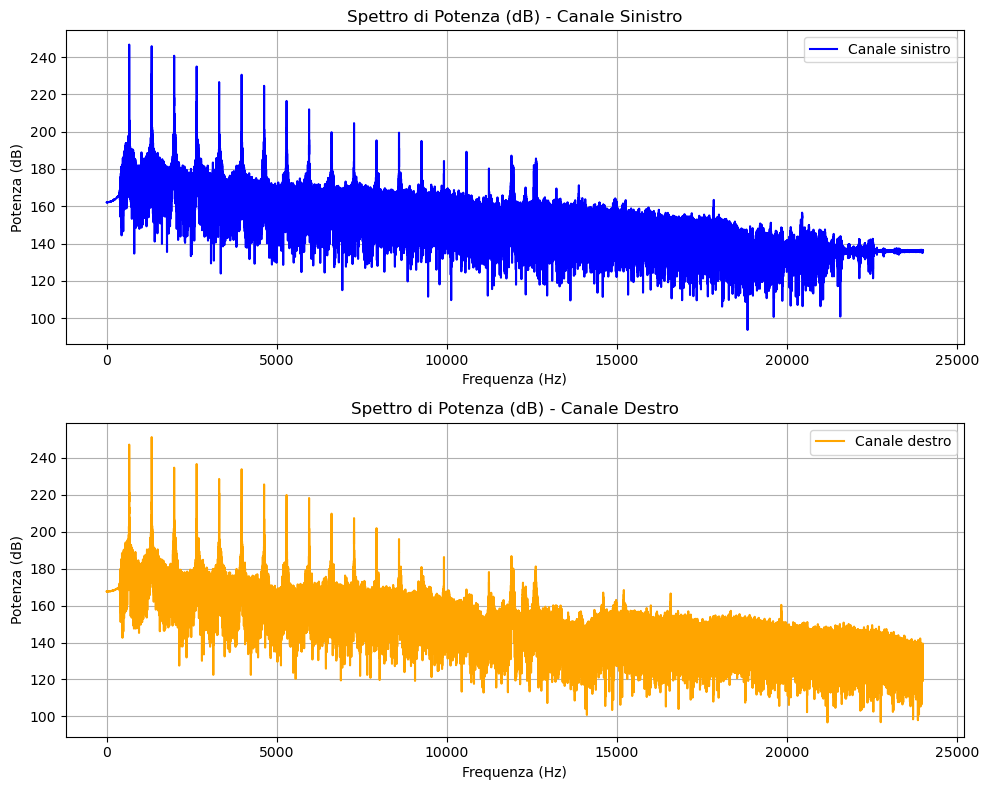

In [39]:
"""Plot degli spettri di potenza in dB."""

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
axes[0].plot(frequencies, 10 * np.log10(power_spectrum_sx), label='Canale sinistro', color='blue')
axes[0].set_title('Spettro di Potenza (dB) - Canale Sinistro')
axes[0].set_xlabel('Frequenza (Hz)')
axes[0].set_ylabel('Potenza (dB)')
axes[0].grid(True)
axes[0].legend()    
axes[1].plot(frequencies, 10 * np.log10(power_spectrum_dx), label='Canale destro', color='orange')
axes[1].set_title('Spettro di Potenza (dB) - Canale Destro')
axes[1].set_xlabel('Frequenza (Hz)')
axes[1].set_ylabel('Potenza (dB)')
axes[1].grid(True)
axes[1].legend()
plt.tight_layout()
plt.show()

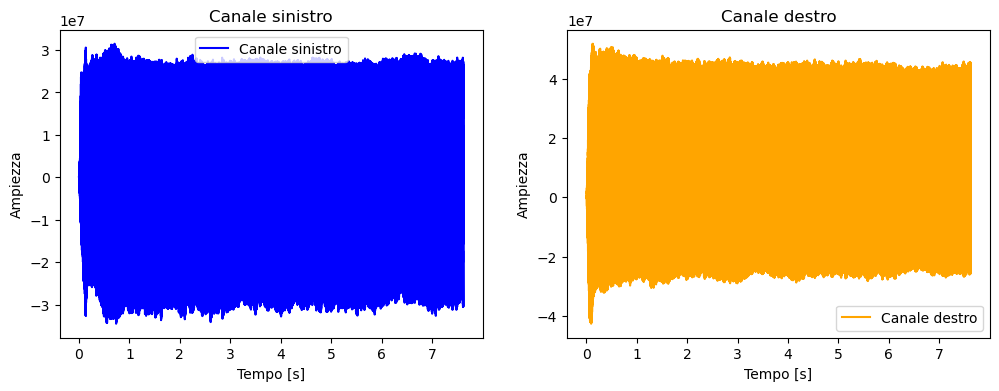

In [31]:
""" Calcola il tempo in secondi per ogni campione e crea un array di tempo corrispondente alla forma d'onda."""

length = data.shape[0] / samplerate
time = np.linspace(0., length, data.shape[0])

""" Visualizza la forma d'onda."""

fig, axes = plt.subplots(ncols = 2, figsize=(12, 4))

ax = axes[0]
ax.plot(time, data[:, 0], label='Canale sinistro', color='blue')
ax.set_xlabel("Tempo [s]")
ax.set_ylabel("Ampiezza")
ax.set_title("Canale sinistro")
ax.legend()

ax = axes[1]
ax.plot(time, data[:, 1], label='Canale destro', color='orange')
ax.set_xlabel("Tempo [s]")
ax.set_ylabel("Ampiezza")
ax.set_title("Canale destro")
ax.legend()

plt.show()